# Intel Image Classification — Simple CNN
**오늘 한 줄**: 70%에서 멈추는 건 모델이 게으른 게 아니라, 구조가 부족한 거다.

흐름: 데이터 확인 → Simple CNN 학습 → 약점 분석 → 튜닝으로 개선

> 데이터: [puneet6060/intel-image-classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if 'seg_train' in dirs:
        print(f'BASE: {root}')
        break

BASE: /kaggle/input/datasets/puneet6060/intel-image-classification


In [2]:
# 한글폰트 필요하면
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess

# 폰트 설치
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

# 설치된 나눔 폰트 경로 직접 찾기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f'폰트 적용: {prop.get_name()}')

폰트 적용: NanumGothic


## [1] 환경 준비

In [3]:
import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 시드 고정
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# 경로 자동 탐색
BASE = '/kaggle/input/datasets/puneet6060/intel-image-classification'
for root, dirs, files in os.walk(BASE):
    if 'seg_train' in dirs:
        BASE = root
        break

TRAIN_DIR = os.path.join(BASE, 'seg_train', 'seg_train')
TEST_DIR  = os.path.join(BASE, 'seg_test',  'seg_test')
print(f'train exists: {os.path.exists(TRAIN_DIR)}')
print(f'test  exists: {os.path.exists(TEST_DIR)}')

device: cuda
train exists: True
test  exists: True


## [2] EDA — 클래스 분포 + 이미지 직접 보기
**볼 것**: 어떤 클래스 쌍이 시각적으로 비슷한가? → 오늘 약점 후보

클래스별 이미지 수
  buildings   : 2191
  forest      : 2271
  glacier     : 2404
  mountain    : 2512
  sea         : 2274
  street      : 2382


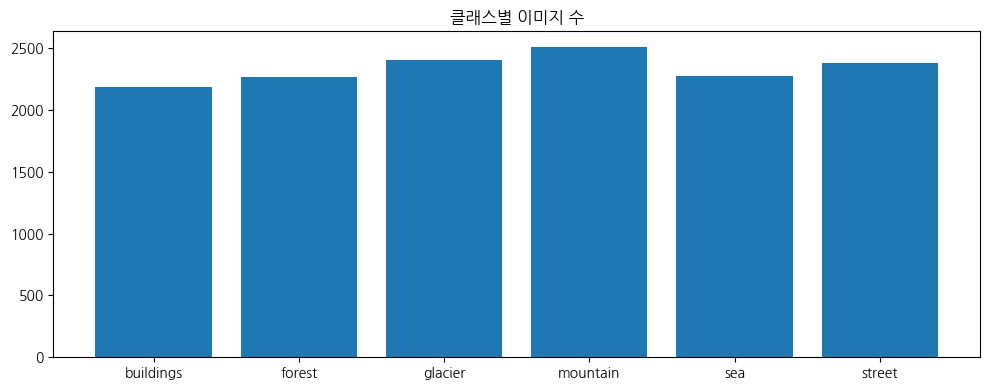

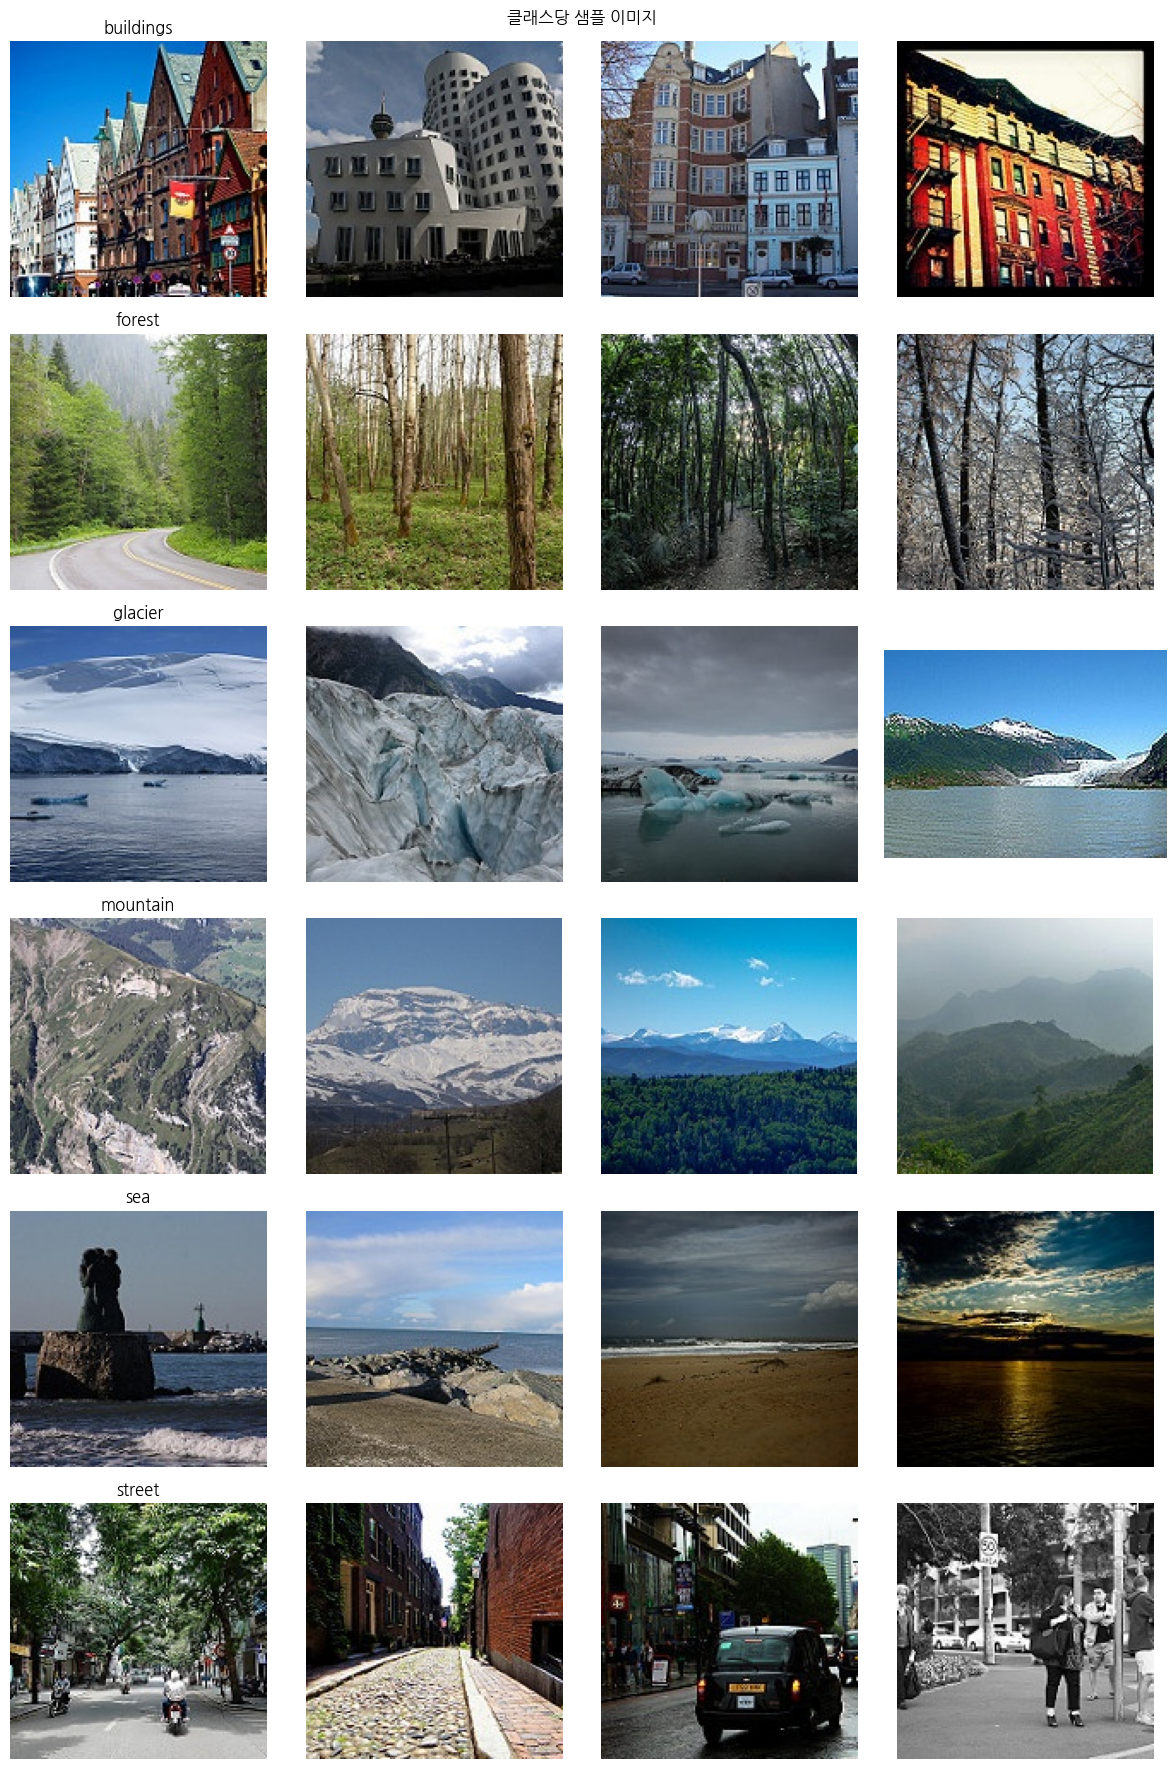

In [4]:
classes = sorted(os.listdir(TRAIN_DIR))
counts  = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

print('클래스별 이미지 수')
for c, n in zip(classes, counts):
    print(f'  {c:<12}: {n}')

plt.figure(figsize=(10, 4))
plt.bar(classes, counts)
plt.title('클래스별 이미지 수'); plt.tight_layout(); plt.show()

# 클래스당 4장씩 보기
from PIL import Image
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3*len(classes)))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs = random.sample(os.listdir(cls_dir), 4)
    for j, img_file in enumerate(imgs):
        img = Image.open(os.path.join(cls_dir, img_file))
        axes[i,j].imshow(img)
        axes[i,j].set_title(cls if j==0 else '')
        axes[i,j].axis('off')
plt.suptitle('클래스당 샘플 이미지'); plt.tight_layout(); plt.show()

**가설 적기**: 어떤 클래스끼리 헷갈릴 것 같나요? 한 줄 적어두세요.

> glacier와 mountain이 색감과 질감이 비슷해서 모델이 헷갈릴 것이다.
> 
> Street 에도 building이 같이 있어서 모델이 헷갈릴 것이다.

## [3] DataLoader 준비
속도가 느리면 numworkers=4로 늘리고 pinmemory=True 추가하여 봅니다.
## num_workers
- CPU 코어 수가 상한선. 캐글 T4는 보통 4코어라 4가 적당
- 너무 높으면 오히려 프로세스 생성 오버헤드로 느려짐
- 데이터셋이 작으면 num_workers=2 가 더 빠를 수도 있음
## pin_memory
- GPU 있을 때만 효과 있음. CPU only면 오히려 메모리 낭비
## batch_size
- 크면 GPU 메모리 한계에 걸림
- 캐글 T4 기준 64×64 이미지면 배치 128~256까지는 보통 괜찮음
- OOM 나면 절반으로 줄이면 됩니다

In [5]:
IMG_SIZE = 64
BATCH    = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_full = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=transform)

# train / val 분할
n_val   = int(len(train_full) * 0.15)
n_train = len(train_full) - n_val
train_ds, val_ds = random_split(train_full, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

print(f'train {n_train} | val {n_val} | test {len(test_ds)}')
print(f'클래스: {train_full.classes}')

train 11929 | val 2105 | test 3000
클래스: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## [4] Simple CNN 모델 정의
Conv2d → BN → ReLU → MaxPool 블록 3개. 이게 베이스라인입니다.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # 블록 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 블록 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 블록 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'총 파라미터 수: {total_params:,}')
print(model)

총 파라미터 수: 2,192,198
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


## [5] 학습 함수 + v1 기본 학습

In [7]:
def train(model, train_dl, val_dl, epochs=30, lr=1e-3, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_acc": [],
                "val_acc": []}


    best_acc, no_improve, best_state = 0, 0, None
    for epoch in range(1, epochs+1):
        # train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total   += len(labels)
        # val
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += len(labels)
        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f'Epoch {epoch:2d} | loss {train_loss/len(train_dl):.4f} | '
              f'train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')
        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}'); break
    model.load_state_dict(best_state)
    return model, history

model_v1 = SimpleCNN().to(device)
model_v1, hist_v1 = train(model_v1, train_dl, val_dl)

Epoch  1 | loss 1.0077 | train_acc 0.6091 | val_acc 0.7007
Epoch  2 | loss 0.6924 | train_acc 0.7441 | val_acc 0.7572
Epoch  3 | loss 0.5703 | train_acc 0.7915 | val_acc 0.7834
Epoch  4 | loss 0.4690 | train_acc 0.8302 | val_acc 0.8048
Epoch  5 | loss 0.3738 | train_acc 0.8667 | val_acc 0.8067
Epoch  6 | loss 0.2788 | train_acc 0.9010 | val_acc 0.8010
Epoch  7 | loss 0.2052 | train_acc 0.9285 | val_acc 0.7995
Epoch  8 | loss 0.1330 | train_acc 0.9543 | val_acc 0.7952
Epoch  9 | loss 0.0900 | train_acc 0.9697 | val_acc 0.8105
Epoch 10 | loss 0.0628 | train_acc 0.9788 | val_acc 0.8076
Epoch 11 | loss 0.0605 | train_acc 0.9805 | val_acc 0.7919
Epoch 12 | loss 0.0545 | train_acc 0.9832 | val_acc 0.8105
Epoch 13 | loss 0.0396 | train_acc 0.9884 | val_acc 0.8010
Epoch 14 | loss 0.0305 | train_acc 0.9901 | val_acc 0.8090
Early stop at epoch 14


## [6] 약점 분석 (오늘의 핵심)
**볼 것**: 가장 낮은 recall 클래스 / 혼동행렬에서 큰 숫자가 어느 칸에 있는가?

=== v1 Baseline ===

전체 정확도: 80.1%

              precision    recall  f1-score   support

   buildings       0.77      0.74      0.75       437
      forest       0.96      0.90      0.93       474
     glacier       0.80      0.70      0.75       553
    mountain       0.76      0.78      0.77       525
         sea       0.74      0.85      0.80       510
      street       0.80      0.85      0.82       501

    accuracy                           0.80      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



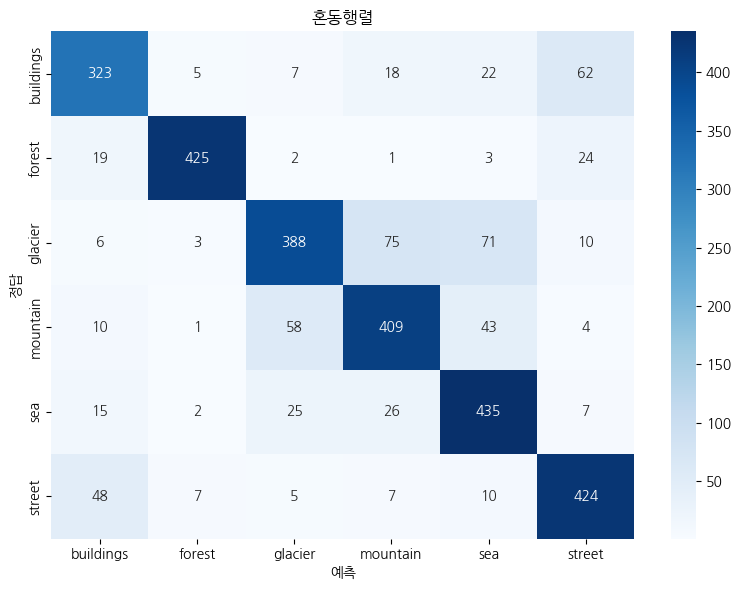

In [8]:
def evaluate(model, test_dl, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    print(f'\n전체 정확도: {acc*100:.1f}%\n')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('혼동행렬'); plt.ylabel('정답'); plt.xlabel('예측')
    plt.tight_layout(); plt.show()
    return acc, all_preds, all_labels

print('=== v1 Baseline ===')
acc_v1, _, _ = evaluate(model_v1, test_dl, train_full.classes)

---
# 여기서부터 튜닝 실험

아래 셀들은 AI 프롬프트로 직접 채워넣으세요.
**한 번에 하나만 바꾸세요.** 두 개를 동시에 바꾸면 어느 게 효과 있었는지 알 수 없습니다.

## [7] v2 — 내가 고른 튜닝 1 

> Batch Normalization 추가


Epoch  1 | loss 1.0404 | train_acc 0.6265 | val_acc 0.7406
Epoch  2 | loss 0.7032 | train_acc 0.7438 | val_acc 0.7924
Epoch  3 | loss 0.6129 | train_acc 0.7794 | val_acc 0.7302
Epoch  4 | loss 0.5571 | train_acc 0.7999 | val_acc 0.8200
Epoch  5 | loss 0.5167 | train_acc 0.8159 | val_acc 0.8010
Epoch  6 | loss 0.4680 | train_acc 0.8292 | val_acc 0.8271
Epoch  7 | loss 0.4432 | train_acc 0.8404 | val_acc 0.7857
Epoch  8 | loss 0.4194 | train_acc 0.8502 | val_acc 0.8423
Epoch  9 | loss 0.3789 | train_acc 0.8621 | val_acc 0.8333
Epoch 10 | loss 0.3513 | train_acc 0.8726 | val_acc 0.8223
Epoch 11 | loss 0.3216 | train_acc 0.8813 | val_acc 0.8418
Epoch 12 | loss 0.3062 | train_acc 0.8898 | val_acc 0.8233
Epoch 13 | loss 0.2835 | train_acc 0.8981 | val_acc 0.8480
Epoch 14 | loss 0.2521 | train_acc 0.9084 | val_acc 0.8285
Epoch 15 | loss 0.2632 | train_acc 0.9037 | val_acc 0.8489
Epoch 16 | loss 0.2225 | train_acc 0.9201 | val_acc 0.8432
Epoch 17 | loss 0.2215 | train_acc 0.9196 | val_acc 0.83

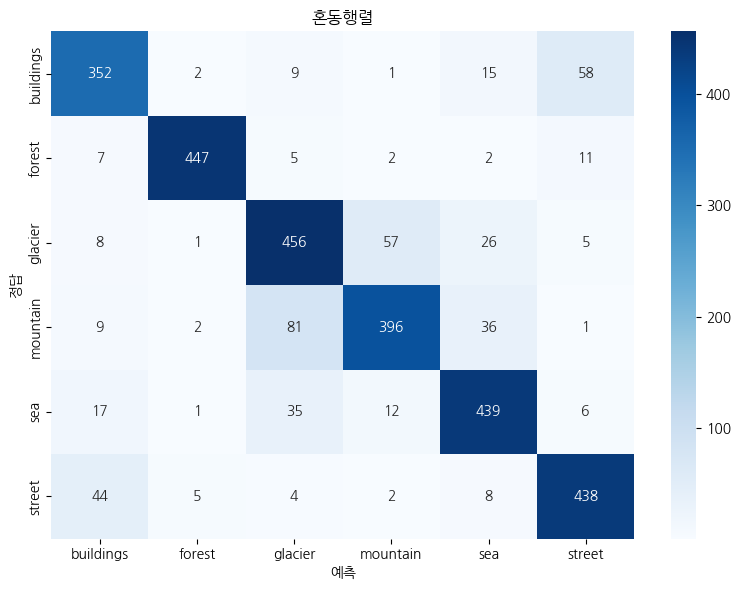

In [9]:
class CNN_v2(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # 블록 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 블록 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 블록 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),   # 🔥 살짝 넣어주는 거 추천
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_v2 = CNN_v2().to(device)
model_v2,hist_v2 = train(model_v2, train_dl, val_dl)


print('=== v2 (BatchNorm) ===')
acc_v2, _, _ = evaluate(model_v2, test_dl, train_full.classes)

## [8] v3 — 내가 고른 튜닝 2

> Dropout 추가

Epoch  1 | loss 1.1607 | train_acc 0.5840 | val_acc 0.7192
Epoch  2 | loss 0.8162 | train_acc 0.7004 | val_acc 0.7558
Epoch  3 | loss 0.7152 | train_acc 0.7432 | val_acc 0.8000
Epoch  4 | loss 0.6700 | train_acc 0.7622 | val_acc 0.7881
Epoch  5 | loss 0.6383 | train_acc 0.7744 | val_acc 0.7701
Epoch  6 | loss 0.5914 | train_acc 0.7911 | val_acc 0.8086
Epoch  7 | loss 0.5567 | train_acc 0.8017 | val_acc 0.8005
Epoch  8 | loss 0.5463 | train_acc 0.8058 | val_acc 0.8029
Epoch  9 | loss 0.5381 | train_acc 0.8103 | val_acc 0.8309
Epoch 10 | loss 0.5075 | train_acc 0.8202 | val_acc 0.8223
Epoch 11 | loss 0.4933 | train_acc 0.8247 | val_acc 0.8266
Epoch 12 | loss 0.4687 | train_acc 0.8361 | val_acc 0.8366
Epoch 13 | loss 0.4479 | train_acc 0.8400 | val_acc 0.7886
Epoch 14 | loss 0.4511 | train_acc 0.8394 | val_acc 0.8347
Epoch 15 | loss 0.4225 | train_acc 0.8513 | val_acc 0.8252
Epoch 16 | loss 0.4170 | train_acc 0.8488 | val_acc 0.8337
Epoch 17 | loss 0.3905 | train_acc 0.8582 | val_acc 0.83

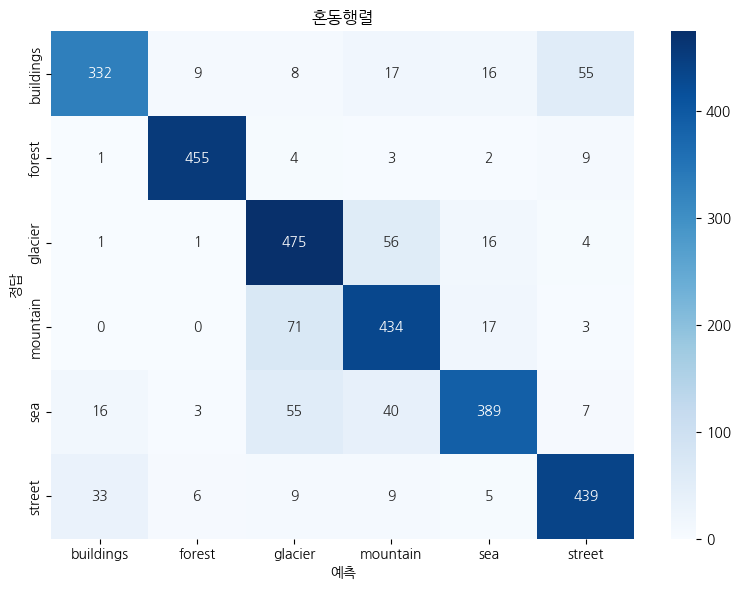

In [10]:
class CNN_v3(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # 블록 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),

            # 블록 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # 블록 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),   # 🔥 여기 핵심 (강하게)
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_v3 = CNN_v3().to(device)
model_v3,hist_v3 = train(model_v3, train_dl, val_dl)

print('=== v3 (Dropout 강화) ===')
acc_v3, _, _ = evaluate(model_v3, test_dl, train_full.classes)

## [9] v4 — 내가 고른 튜닝 3

> 학습스케줄러추가

In [14]:
from torch.optim.lr_scheduler import StepLR

def train_v4(model, train_dl, val_dl, epochs=30, lr=1e-3, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
    # 👉 10 epoch마다 lr 절반으로 감소

    history = {
    "train_acc": [],
    "val_acc": []
}

    best_acc, no_improve, best_state = 0, 0, None

    for epoch in range(1, epochs+1):
        # train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += len(labels)

        # val
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += len(labels)

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f'Epoch {epoch:2d} | lr {scheduler.get_last_lr()[0]:.6f} | '
              f'loss {train_loss/len(train_dl):.4f} | '
              f'train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')

        # 🔥 Early stopping
        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break

        scheduler.step()  # 🔥 여기 중요

    model.load_state_dict(best_state)
    return model, history

model_v4 = CNN_v3().to(device)  # v3 구조 그대로 사용
model_v4,hist_v4 = train_v4(model_v4, train_dl, val_dl)

Epoch  1 | lr 0.001000 | loss 1.1058 | train_acc 0.5902 | val_acc 0.6922
Epoch  2 | lr 0.001000 | loss 0.8354 | train_acc 0.6917 | val_acc 0.7406
Epoch  3 | lr 0.001000 | loss 0.7554 | train_acc 0.7246 | val_acc 0.7867
Epoch  4 | lr 0.001000 | loss 0.6768 | train_acc 0.7584 | val_acc 0.7587
Epoch  5 | lr 0.001000 | loss 0.6565 | train_acc 0.7638 | val_acc 0.7876
Epoch  6 | lr 0.001000 | loss 0.6052 | train_acc 0.7866 | val_acc 0.7971
Epoch  7 | lr 0.001000 | loss 0.5814 | train_acc 0.7922 | val_acc 0.8223
Epoch  8 | lr 0.001000 | loss 0.5465 | train_acc 0.8064 | val_acc 0.8352
Epoch  9 | lr 0.001000 | loss 0.5388 | train_acc 0.8093 | val_acc 0.8014
Epoch 10 | lr 0.001000 | loss 0.4949 | train_acc 0.8288 | val_acc 0.8290
Epoch 11 | lr 0.000500 | loss 0.4302 | train_acc 0.8464 | val_acc 0.8489
Epoch 12 | lr 0.000500 | loss 0.4175 | train_acc 0.8530 | val_acc 0.8508
Epoch 13 | lr 0.000500 | loss 0.4060 | train_acc 0.8535 | val_acc 0.8304
Epoch 14 | lr 0.000500 | loss 0.4034 | train_acc 0.

=== v4 (스케줄러 강화) ===

전체 정확도: 86.7%

              precision    recall  f1-score   support

   buildings       0.87      0.81      0.84       437
      forest       0.96      0.98      0.97       474
     glacier       0.84      0.80      0.82       553
    mountain       0.81      0.85      0.83       525
         sea       0.85      0.90      0.87       510
      street       0.89      0.87      0.88       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



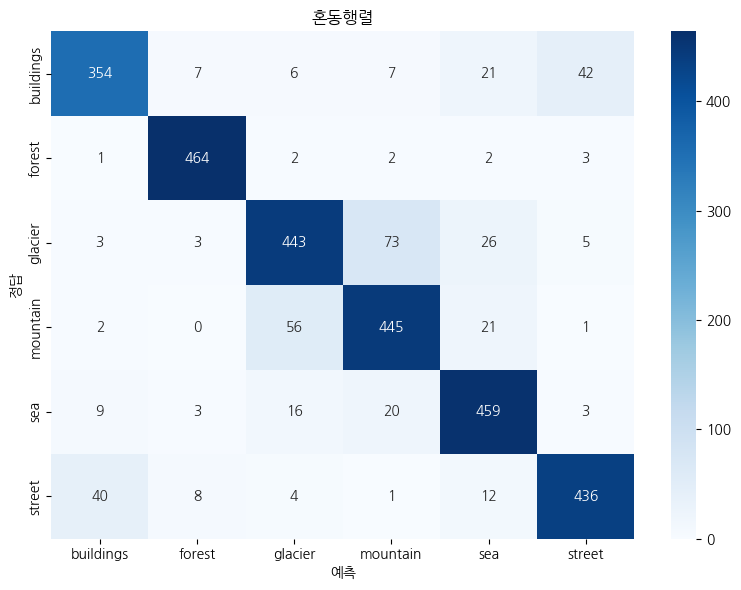

In [15]:
print('=== v4 (스케줄러 강화) ===')
acc_v4, _, _ = evaluate(model_v4, test_dl, train_full.classes)

## [10] 결과 비교 표

v1~v4 결과를 한 표로 정리하세요. AI에게 맡겨도 됩니다.

In [16]:
import pandas as pd
from sklearn.metrics import classification_report

def get_metrics_dict(model, test_dl, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True
    )

    acc = report['accuracy']
    recalls = {cls: report[cls]['recall'] for cls in class_names}
    weakest_cls = min(recalls, key=recalls.get)
    weakest_recall = recalls[weakest_cls]

    return acc, recalls, weakest_cls, weakest_recall

In [17]:
results = {}

for name, model in {
    "v1": model_v1,
    "v2": model_v2,
    "v3": model_v3,
    "v4": model_v4,
}.items():
    acc, recalls, weakest_cls, weakest_recall = get_metrics_dict(
        model, test_dl, train_full.classes
    )

    row = {
        "accuracy": acc,
        **recalls,
        "weakest_class": weakest_cls,
        "weakest_recall": weakest_recall
    }

    results[name] = row

df = pd.DataFrame(results)
df

,v1,v2,v3,v4
accuracy,0.801333,0.842667,0.841333,0.867
buildings,0.73913,0.805492,0.759725,0.810069
forest,0.896624,0.943038,0.959916,0.978903
glacier,0.701627,0.824593,0.858951,0.801085
mountain,0.779048,0.754286,0.826667,0.847619
sea,0.852941,0.860784,0.762745,0.9
street,0.846307,0.874251,0.876248,0.870259
weakest_class,glacier,mountain,buildings,glacier
weakest_recall,0.701627,0.754286,0.759725,0.801085


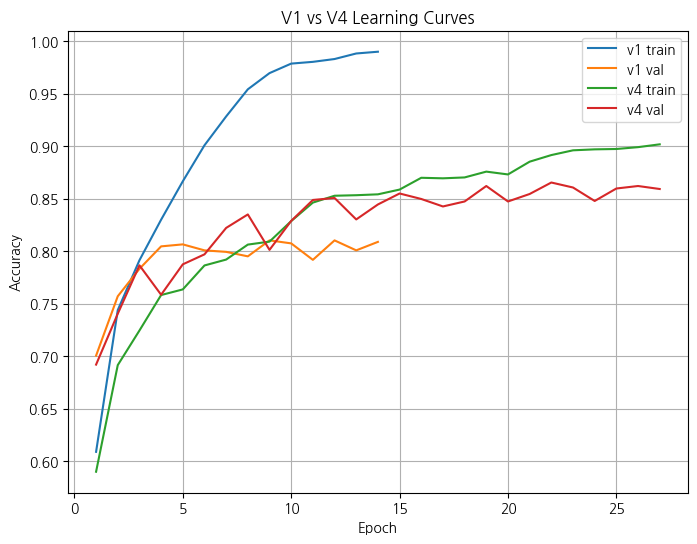

In [22]:
import matplotlib.pyplot as plt

def plot_v1_v4(hist_v1, hist_v4):
    epochs_v1 = range(1, len(hist_v1["train_acc"]) + 1)
    epochs_v4 = range(1, len(hist_v4["train_acc"]) + 1)

    plt.figure(figsize=(8,6))

    # v1
    plt.plot(epochs_v1, hist_v1["train_acc"], label="v1 train")
    plt.plot(epochs_v1, hist_v1["val_acc"], label="v1 val")

    # v4
    plt.plot(epochs_v4, hist_v4["train_acc"], label="v4 train")
    plt.plot(epochs_v4, hist_v4["val_acc"], label="v4 val")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("V1 vs V4 Learning Curves")
    plt.legend()
    plt.grid()

    plt.show()


# 비교 결과
plot_v1_v4(hist_v1, hist_v4)